# 策略三：季节性效应

## 核心思路

市场存在可重复的**日历规律**。不是所有时间段持有股票都值得，某些特定时段的风险调整收益显著更高。

## 研究的五类规律

1. **月份效应**：一月效应（January Effect）、年末效应等
2. **星期效应**：周一效应（Monday Effect）、周五效应
3. **月末月初效应（TOM）**：每月最后4天 + 下月前3天，收益率系统性偏高
4. **"五月卖出"（Sell in May）**：持有10月–4月，空仓5月–9月
5. **综合季节性信号**：多条件叠加评分

## 统计检验

每种规律均进行 **t 检验**，报告 t 统计量和 p 值，判断是否具有统计显著性。

## 数据

- 来源：`yfinance` SPY 日线，1993年1月至2024年12月
- 样本量：约 8000 个交易日，统计功效充足

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

In [2]:
# --- Download SPY data ---
raw = yf.download('SPY', start='1993-01-01', end='2024-12-31',
                  auto_adjust=True, progress=False)
# yfinance >= 1.x returns DataFrame even for single ticker; squeeze to Series
spy_close = raw['Close']
spy = spy_close.squeeze() if isinstance(spy_close, pd.DataFrame) else spy_close
spy = spy.rename('SPY')
daily_ret = spy.pct_change().dropna()

df = pd.DataFrame({'close': spy, 'ret': daily_ret}).dropna()
df['month'] = df.index.month
df['dow']   = df.index.dayofweek   # 0=Mon, 4=Fri
df['year']  = df.index.year

# Days relative to month boundary (pandas 3.x compatible)
df['_period']          = df.index.to_period('M')
df['month_start_rank'] = df.groupby('_period').cumcount()          # 0 = first day of month
month_size             = df.groupby('_period')['ret'].transform('count')
df['month_end_rank']   = df['month_start_rank'] - month_size + 1   # -1 = last day, 0 = day after last
df.drop(columns='_period', inplace=True)

print(f"SPY data: {df.index[0].date()} to {df.index[-1].date()}  ({len(df)} days)")

SPY data: 1993-02-01 to 2024-12-30  (8036 days)


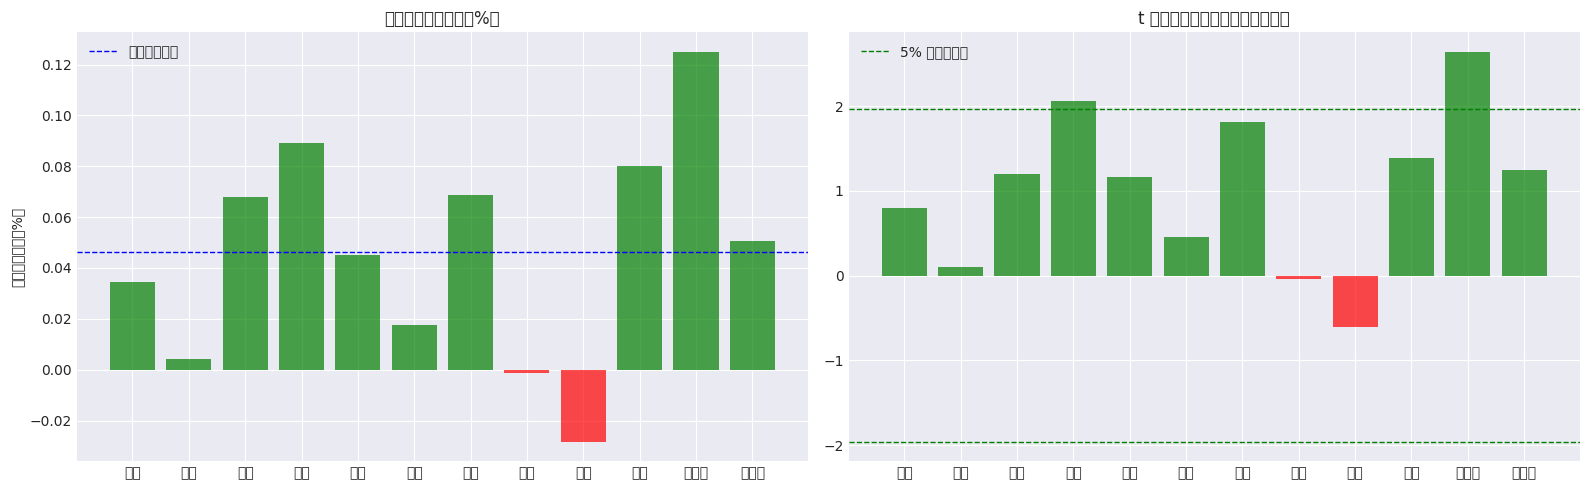


月份效应统计结果：
       mean  ann_ret  t_stat  p_value
一月   0.0003   0.0872  0.7933   0.4279
二月   0.0000   0.0111  0.1041   0.9171
三月   0.0007   0.1709  1.2032   0.2293
四月   0.0009   0.2251  2.0609   0.0397
五月   0.0005   0.1139  1.1645   0.2447
六月   0.0002   0.0438  0.4535   0.6504
七月   0.0007   0.1736  1.8084   0.0710
八月  -0.0000  -0.0037 -0.0349   0.9722
九月  -0.0003  -0.0713 -0.6017   0.5476
十月   0.0008   0.2020  1.3896   0.1651
十一月  0.0013   0.3150  2.6404   0.0085
十二月  0.0005   0.1272  1.2482   0.2124


In [3]:
# ══════════════════════════════════════════════════════
# 一、月份效应（Month-of-Year Effect）
# ══════════════════════════════════════════════════════
month_stats = df.groupby('month')['ret'].agg(['mean', 'std', 'count']).copy()
month_stats['ann_ret'] = month_stats['mean'] * 252  # 年化收益近似
month_stats['t_stat']  = month_stats['mean'] / (month_stats['std'] / np.sqrt(month_stats['count']))
avg_dof = month_stats['count'].mean() - 1
month_stats['p_value'] = month_stats['t_stat'].apply(
    lambda t: stats.t.sf(abs(t), df=avg_dof) * 2   # 双尾 p 值
)
month_names = ['一月','二月','三月','四月','五月','六月',
               '七月','八月','九月','十月','十一月','十二月']
month_stats.index = month_names

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = ['green' if m > 0 else 'red' for m in month_stats['mean']]

axes[0].bar(month_stats.index, month_stats['mean'] * 100, color=colors, alpha=0.7)
axes[0].axhline(daily_ret.mean() * 100, color='blue', ls='--', lw=1, label='整体日均收益')
axes[0].set_title('各月平均日收益率（%）', fontsize=12)
axes[0].set_ylabel('平均日收益率（%）')
axes[0].legend()

axes[1].bar(month_stats.index, month_stats['t_stat'], color=colors, alpha=0.7)
axes[1].axhline( 1.96, color='green', ls='--', lw=1, label='5% 显著性水平')
axes[1].axhline(-1.96, color='green', ls='--', lw=1)
axes[1].set_title('t 统计量（月份效应显著性检验）', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()

print("\n月份效应统计结果：")
print(month_stats[['mean', 'ann_ret', 't_stat', 'p_value']].round(4).to_string())

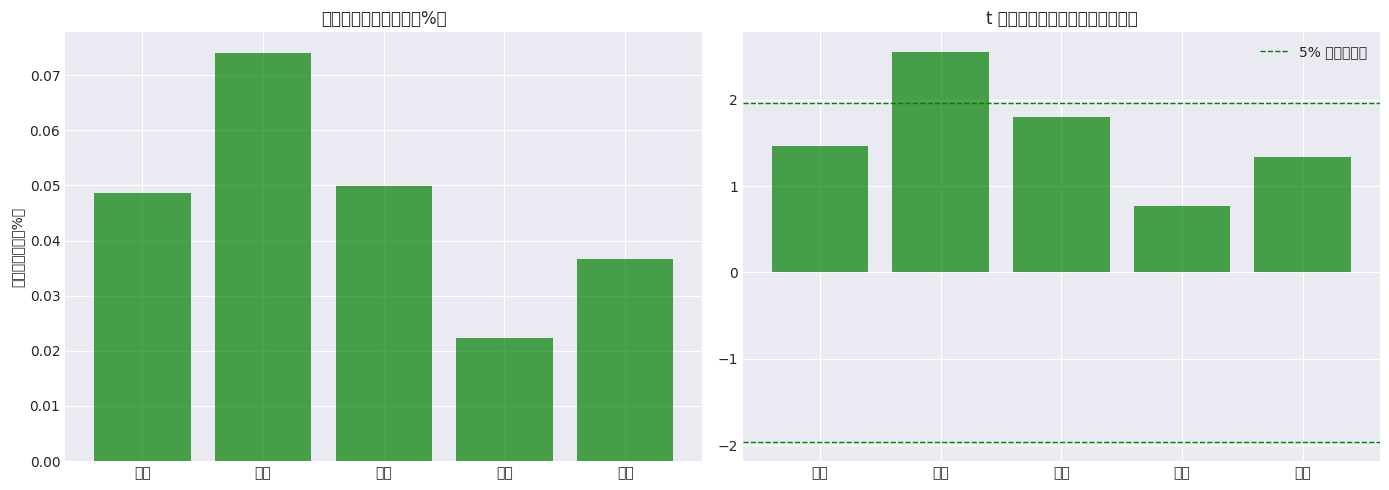

      mean     std  count  t_stat
周一  0.0005  0.0129   1510  1.4620
周二  0.0007  0.0118   1649  2.5564
周三  0.0005  0.0112   1648  1.8061
周四  0.0002  0.0117   1619  0.7694
周五  0.0004  0.0110   1610  1.3382


In [4]:
# ══════════════════════════════════════════════════════
# 二、星期效应（Day-of-Week Effect）
# 研究问题：周几持有股票的平均收益最高？
# ══════════════════════════════════════════════════════
dow_stats = df.groupby('dow')['ret'].agg(['mean', 'std', 'count']).copy()
dow_stats['t_stat'] = dow_stats['mean'] / (dow_stats['std'] / np.sqrt(dow_stats['count']))
dow_stats.index = ['周一', '周二', '周三', '周四', '周五']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['green' if m > 0 else 'red' for m in dow_stats['mean']]

axes[0].bar(dow_stats.index, dow_stats['mean'] * 100, color=colors, alpha=0.7)
axes[0].set_title('各星期平均日收益率（%）', fontsize=12)
axes[0].set_ylabel('平均日收益率（%）')

axes[1].bar(dow_stats.index, dow_stats['t_stat'], color=colors, alpha=0.7)
axes[1].axhline( 1.96, color='green', ls='--', lw=1, label='5% 显著性水平')
axes[1].axhline(-1.96, color='green', ls='--', lw=1)
axes[1].set_title('t 统计量（星期效应显著性检验）', fontsize=12)
axes[1].legend()
plt.tight_layout()
plt.show()

print(dow_stats.round(4).to_string())

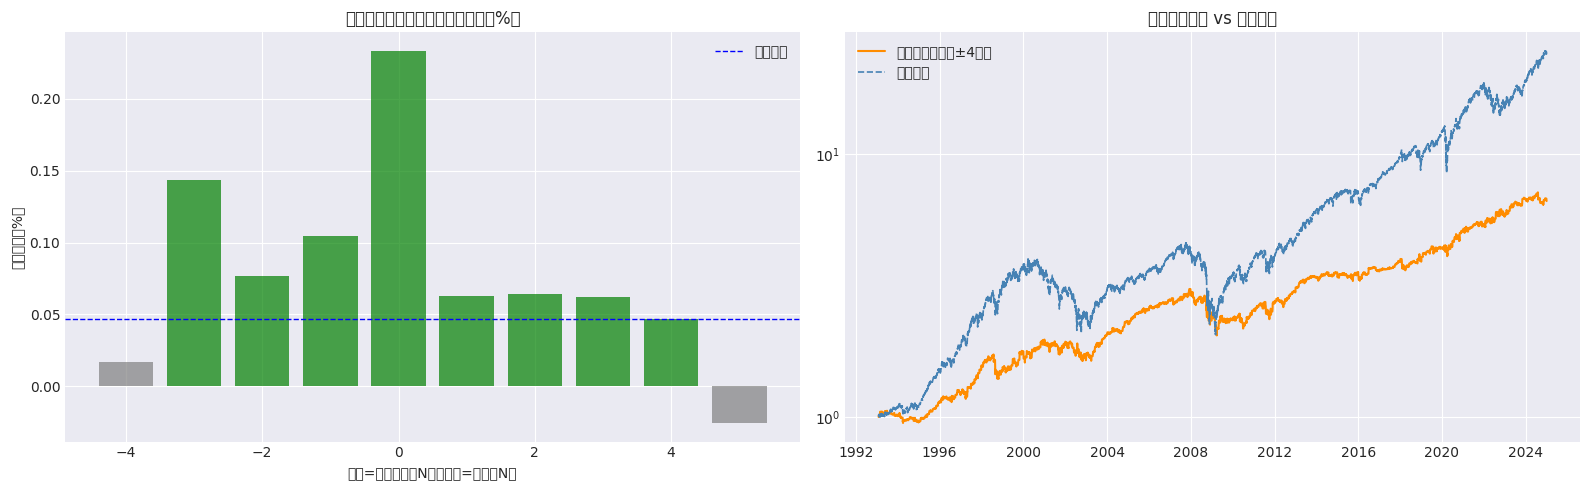

月末月初期间日均收益：0.0892%
其余时间日均收益：    0.0250%
月末月初期间收益是其余时间的 3.6 倍


In [5]:
# ══════════════════════════════════════════════════════
# 三、月末月初效应（Turn-of-Month Effect）
# 观察：每月最后几天和下月初几天的收益率系统性偏高
# 解释：月末资金流入（养老金定投、工资再投资等）
# ══════════════════════════════════════════════════════
TOM_WINDOW = 4  # 月末最后4天 + 下月前3天

# month_end_rank: -1 = 倒数第1个交易日, -2 = 倒数第2个, ...
# month_start_rank: 0 = 本月第1个交易日, 1 = 第2个, ...
is_tom = (
    (df['month_end_rank'] >= -TOM_WINDOW + 1) & (df['month_end_rank'] <= 0)
) | (
    (df['month_start_rank'] >= 0) & (df['month_start_rank'] < TOM_WINDOW - 1)
)

tom_ret     = df.loc[is_tom,  'ret'].mean()
non_tom_ret = df.loc[~is_tom, 'ret'].mean()

# 月末月初策略回测（仅在 TOM 窗口内持有）
tom_strat_ret = df['ret'] * is_tom.astype(int).shift(1)
bh_ret        = df['ret']
tom_equity    = (1 + tom_strat_ret.dropna()).cumprod()
bh_equity     = (1 + bh_ret.dropna()).cumprod()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 月末月初附近各交易日的平均收益
days    = list(range(-TOM_WINDOW, TOM_WINDOW + 2))
day_avgs = []
for d in days:
    mask = (df['month_end_rank'] == d) if d < 0 else (df['month_start_rank'] == d)
    day_avgs.append(df.loc[mask, 'ret'].mean() * 100)

colors = ['green' if v > daily_ret.mean() * 100 else 'grey' for v in day_avgs]
axes[0].bar(days, day_avgs, color=colors, alpha=0.7)
axes[0].axhline(daily_ret.mean() * 100, color='blue', ls='--', lw=1, label='整体均值')
axes[0].set_title('月末月初附近各交易日平均收益（%）', fontsize=12)
axes[0].set_xlabel('负数=月末倒数第N天，正数=月初第N天')
axes[0].set_ylabel('平均收益（%）')
axes[0].legend()

axes[1].plot(tom_equity.index, tom_equity.values,
             label=f'月末月初策略（±{TOM_WINDOW}天）', color='darkorange', lw=1.5)
axes[1].plot(bh_equity.index,  bh_equity.values,
             label='买入持有', color='steelblue', lw=1.2, ls='--')
axes[1].set_title('月末月初策略 vs 买入持有', fontsize=12)
axes[1].legend()
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

print(f"月末月初期间日均收益：{tom_ret*100:.4f}%")
print(f"其余时间日均收益：    {non_tom_ret*100:.4f}%")
print(f"月末月初期间收益是其余时间的 {tom_ret/non_tom_ret:.1f} 倍")

"五月卖出"（10月–4月持有）                     年化=8.9%  波动=19.8%  夏普=0.45  最大回撤=-46.1%
SPY 买入持有                             年化=10.5%  波动=18.7%  夏普=0.56  最大回撤=-55.2%


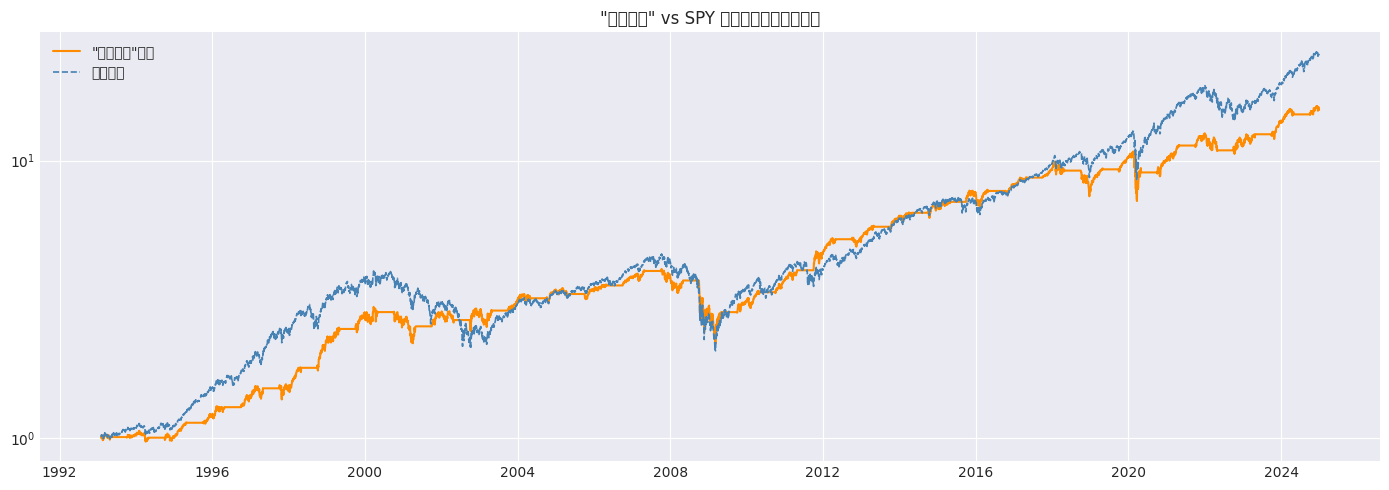

In [6]:
# ══════════════════════════════════════════════════════
# 四、"五月卖出"（Sell in May / Halloween Effect）
# 策略：10月–4月持有，5月–9月空仓
# 逻辑：夏季成交量低、机构休假，市场表现历史上偏弱
# ══════════════════════════════════════════════════════
in_market = df['month'].isin([10, 11, 12, 1, 2, 3, 4])  # 持有月份：10月到次年4月

sim_ret   = df['ret'] * in_market.shift(1).fillna(0)
sim_equity = (1 + sim_ret).cumprod()
bh_equity  = (1 + df['ret']).cumprod()

def perf(ret, label):
    """打印策略绩效摘要。"""
    active  = ret[ret != 0]
    ann_ret = (1 + ret).prod() ** (252 / len(ret)) - 1
    ann_vol = active.std() * np.sqrt(252)
    cum     = (1 + ret).cumprod()
    dd      = ((cum - cum.cummax()) / cum.cummax()).min()
    sharpe  = ann_ret / ann_vol if ann_vol else 0
    print(f"{label:35s}  年化={ann_ret*100:.1f}%  波动={ann_vol*100:.1f}%  "
          f"夏普={sharpe:.2f}  最大回撤={dd*100:.1f}%")

perf(sim_ret,    '"五月卖出"（10月–4月持有）')
perf(df['ret'],  'SPY 买入持有')

plt.figure(figsize=(14, 5))
plt.plot(sim_equity.index, sim_equity.values, label='"五月卖出"策略', color='darkorange', lw=1.5)
plt.plot(bh_equity.index,  bh_equity.values,  label='买入持有',        color='steelblue',  lw=1.2, ls='--')
plt.title('"五月卖出" vs SPY 买入持有（对数坐标）', fontsize=12)
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.savefig('../data/seasonality_results.png', dpi=120, bbox_inches='tight')
plt.show()

综合季节性策略（评分≥2）                        年化=4.7%  波动=18.7%  夏普=0.25  最大回撤=-29.8%
SPY 买入持有                             年化=10.5%  波动=18.7%  夏普=0.56  最大回撤=-55.2%


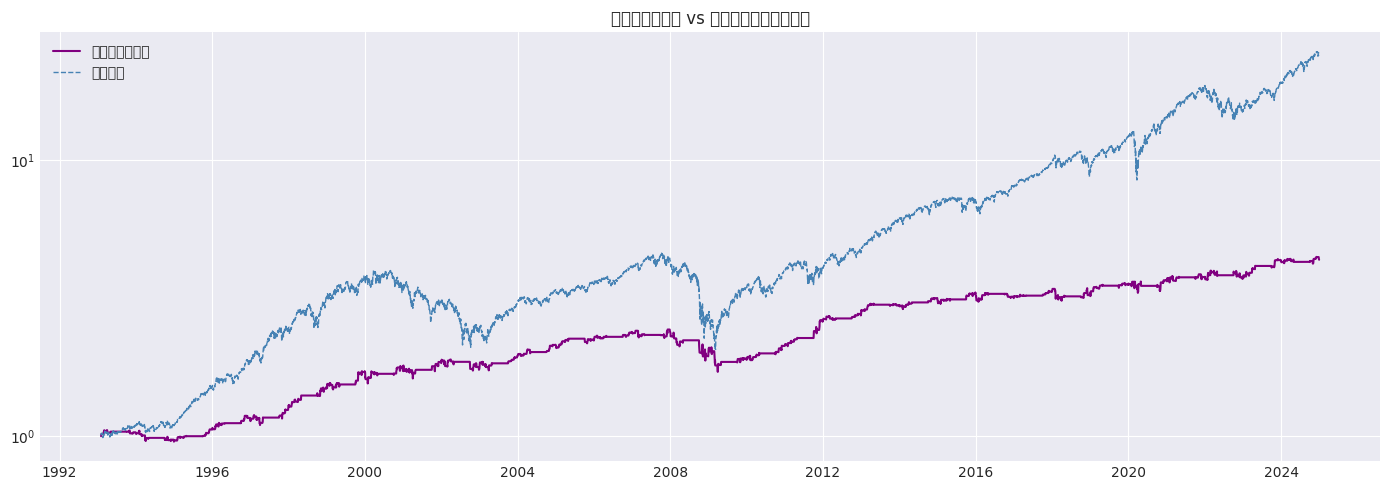

In [7]:
# ══════════════════════════════════════════════════════
# 五、综合季节性策略：多条件叠加评分
# 同时满足多个有利条件时才持仓，提升胜率
# ══════════════════════════════════════════════════════
score = pd.Series(0.0, index=df.index)
score += in_market.astype(int)                    # +1：处于"强势半年"（10月–4月）
score += is_tom.astype(int)                       # +1：月末月初窗口
score += (df['dow'] != 0).astype(float) * 0.5    # +0.5：不是周一（避开周末效应）

# 评分 ≥ 2 时才持仓（强季节性叠加）
combined_signal = (score >= 2).shift(1).fillna(0)
combined_ret    = df['ret'] * combined_signal

perf(combined_ret, '综合季节性策略（评分≥2）')
perf(df['ret'],    'SPY 买入持有')

cum_combined = (1 + combined_ret).cumprod()
plt.figure(figsize=(14, 5))
plt.plot(cum_combined.index, cum_combined.values, label='综合季节性策略', color='purple', lw=1.5)
plt.plot(bh_equity.index,    bh_equity.values,    label='买入持有',       color='steelblue', lw=1, ls='--')
plt.title('综合季节性策略 vs 买入持有（对数坐标）')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()